# Pretrain & save pose VAEs (+ TCR encoders)

Pretrains the **pose VAEs** (unsupervised) and the **TCR sequence encoders**
(warm-start), and saves them to `REPO/pretrained/` so `train.ipynb` can load
instead of pretraining inline.

Two pose-corpus strategies, each with an ipTM-filter option:
* **binder + non-binder** (`which="all"`) — manifold spans both classes (default).
* **binder only** (`which="binder"`) — one-class / anomaly-style manifold.

Runtime → GPU. Data CSVs in `REPO/data/`.

In [10]:
! git clone https://github.com/92kunheekim/tcrpmhc_pose_binding.git
from google.colab import drive
drive.mount('/content/drive')

fatal: destination path 'tcrpmhc_pose_binding' already exists and is not an empty directory.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys, os
REPO="/content/tcrpmhc_pose_binding"
DATA_DIR=f"/content/drive/MyDrive"
PRETRAIN_DIR=f"/content/drive/MyDrive/tcrpmhc_pose_binding/pretrained"
os.makedirs(PRETRAIN_DIR,exist_ok=True)
sys.path.insert(0,f"{REPO}/src")
print("src:",os.path.isdir(f"{REPO}/src"),"| data:",os.path.isdir(DATA_DIR),"| out:",PRETRAIN_DIR)

src: True | data: True | out: /content/drive/MyDrive/tcrpmhc_pose_binding/pretrained


In [3]:
import subprocess, sys
subprocess.run([sys.executable,"-m","pip","install","-q","-r",f"{REPO}/requirements.txt"])
import json, torch
from data import pose_corpus, load_data
from pose_vae import PoseVAERaw
from train_utils import pretrain_posevae, pretrain_tcr_encoders, DEVICE
print("device:",DEVICE)

device: cuda


## Config

In [5]:
PRETRAIN_EPOCHS = 100   # upper bound; early stop usually ends sooner
PATIENCE        = 8     # stop if recon loss plateaus for this many epochs    # pose VAE epochs (raise for a final run)
TCR_EPOCHS      = 30    # TCR encoder AE epochs
ROT             = ["6d","qnn"]
# corpus strategies (name -> pose_corpus kwargs)
STRATEGIES = {
 "binderNonbinder_iptm05": dict(which="all",      min_iptm=0.5),
 "binderOnly":             dict(which="binder",   min_iptm=None),
 "NonbinderOnly_iptm05":   dict(which="nonbinder",min_iptm=0.5),
 "binderNonbinder_all":    dict(which="all",      min_iptm=None),   # no ipTM filter (extra)
}

## 1. Stage 0 — TCR sequence encoders (label-agnostic, all sequences)

In [6]:
seq = load_data(DATA_DIR, min_iptm=0.5)["seq"]         # full seq table w/ chains
TCR_ENC = pretrain_tcr_encoders(seq, epochs=TCR_EPOCHS)
torch.save(TCR_ENC, f"{PRETRAIN_DIR}/tcr_encoders.pt")
print("saved tcr_encoders.pt  (chains:", list(TCR_ENC), ")")

saved tcr_encoders.pt  (chains: ['va', 'vb', 'cdr3a', 'cdr3b'] )


## 2. Stage 1 — pose VAEs per strategy × rotation encoder

In [7]:
meta = {"trans_scale": None, "strategies": {}, "files": []}
HIST = {}
for sname, cfg in STRATEGIES.items():
    POSE_ALL, trans_scale = pose_corpus(DATA_DIR, **cfg)
    meta["trans_scale"] = trans_scale
    meta["strategies"][sname] = dict(cfg, n=int(len(POSE_ALL)))
    print(f"[{sname}] corpus n={len(POSE_ALL)}  cfg={cfg}")
    for rot in ROT:
        vae, hist = pretrain_posevae(POSE_ALL, rot, epochs=PRETRAIN_EPOCHS, return_history=True, patience=PATIENCE)
        fn = f"posevae_{sname}_{rot}.pt"
        torch.save(vae.state_dict(), f"{PRETRAIN_DIR}/{fn}")
        hist.to_csv(f"{PRETRAIN_DIR}/history_{sname}_{rot}.csv", index=False)
        HIST[(sname, rot)] = hist; meta["files"].append(fn); print("   saved", fn)
json.dump(meta, open(f"{PRETRAIN_DIR}/meta.json","w"), indent=2)
print("\nsaved meta.json | trans_scale =", round(meta["trans_scale"],3))

[binderNonbinder_iptm05] corpus n=9496  cfg={'which': 'all', 'min_iptm': 0.5}
  ep  1 loss=12.659 recon=12.657 KL=0.020 | rot=77.4deg dir=41.7deg reach_rmse=0.320 | active=22/28 kldim=0.053
  ep  5 loss=4.714 recon=4.659 KL=0.550 | rot=34.2deg dir=12.1deg reach_rmse=0.083 | active=27/28 kldim=0.594
  ep 10 loss=4.027 recon=3.917 KL=1.101 | rot=28.4deg dir=11.5deg reach_rmse=0.068 | active=28/28 kldim=1.316
  ep 15 loss=3.564 recon=3.401 KL=1.633 | rot=24.7deg dir=10.5deg reach_rmse=0.063 | active=28/28 kldim=2.029
  ep 20 loss=3.052 recon=2.847 KL=2.050 | rot=20.5deg dir=9.8deg reach_rmse=0.061 | active=28/28 kldim=2.472
  ep 25 loss=2.728 recon=2.503 KL=2.249 | rot=18.2deg dir=9.1deg reach_rmse=0.060 | active=28/28 kldim=2.711
  ep 30 loss=2.573 recon=2.338 KL=2.345 | rot=17.0deg dir=8.7deg reach_rmse=0.060 | active=28/28 kldim=2.832
  ep 35 loss=2.475 recon=2.232 KL=2.437 | rot=16.3deg dir=8.4deg reach_rmse=0.059 | active=28/28 kldim=2.939
  ep 40 loss=2.373 recon=2.123 KL=2.502 | ro

## Convergence diagnostics (is the epoch count enough?)
Reconstruction-loss plateau (#1), rotation/direction error in degrees (#3), and active latent units / KL-per-dim for posterior collapse (#4).

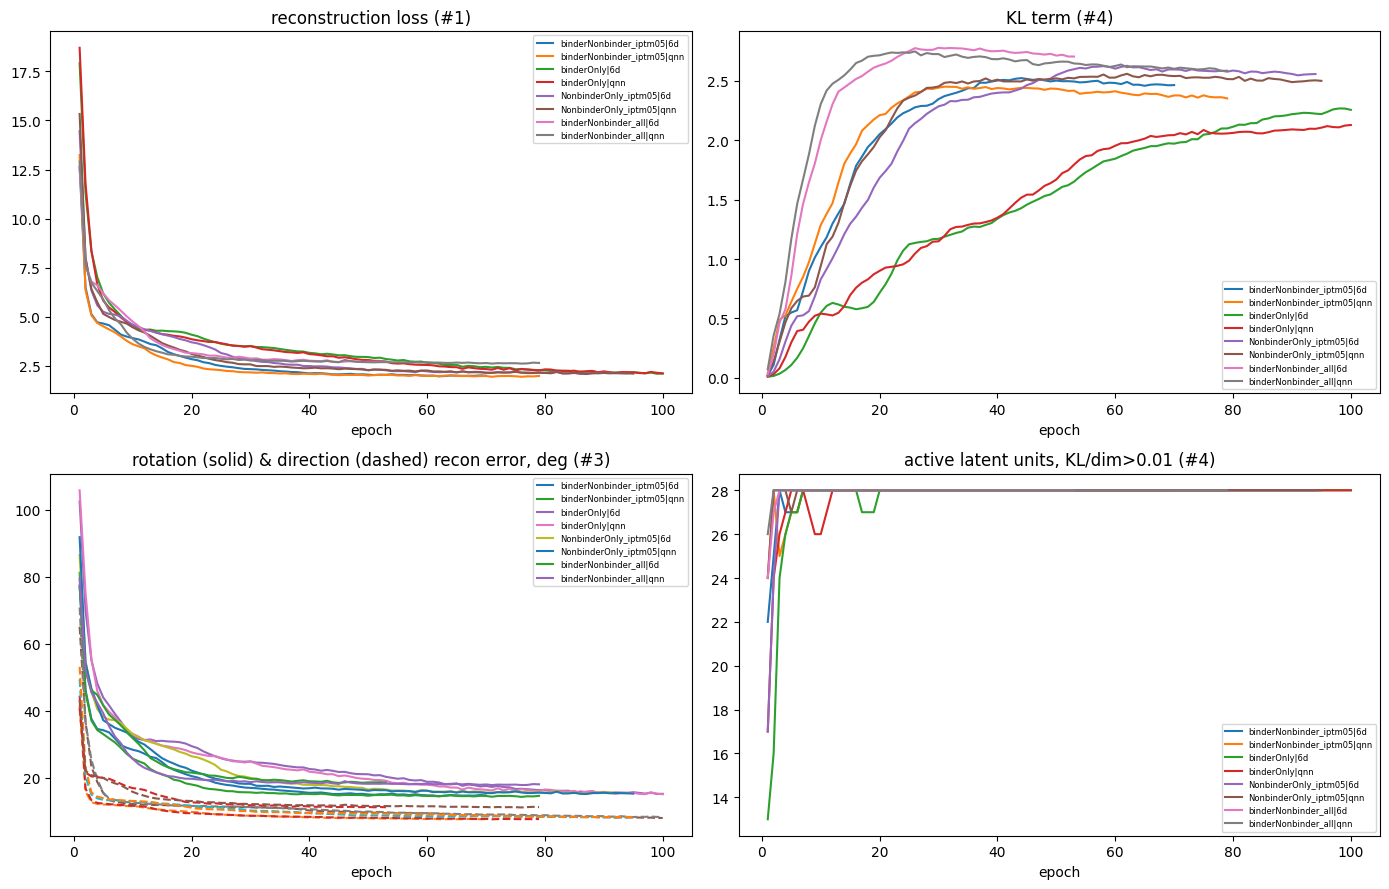

convergence readout (recon slope over last 5 epochs ~0 => plateaued):
  binderNonbinder_iptm05|6d: recon=2.002 slope/ep=+0.0014 | rot=14.7deg dir=7.7deg | active=28 KL/dim=3.075
  binderNonbinder_iptm05|qnn: recon=1.991 slope/ep=+0.0040 | rot=14.6deg dir=7.7deg | active=28 KL/dim=3.097
  binderOnly|6d: recon=2.110 slope/ep=-0.0115 | rot=15.2deg dir=8.0deg | active=28 KL/dim=2.732
  binderOnly|qnn: recon=2.124 slope/ep=-0.0039 | rot=15.1deg dir=8.3deg | active=28 KL/dim=2.739
  NonbinderOnly_iptm05|6d: recon=2.121 slope/ep=-0.0083 | rot=15.5deg dir=8.2deg | active=28 KL/dim=3.214
  NonbinderOnly_iptm05|qnn: recon=2.108 slope/ep=-0.0038 | rot=15.3deg dir=8.3deg | active=28 KL/dim=3.290
  binderNonbinder_all|6d: recon=2.712 slope/ep=+0.0013 | rot=18.6deg dir=11.2deg | active=28 KL/dim=3.458
  binderNonbinder_all|qnn: recon=2.653 slope/ep=+0.0034 | rot=18.1deg dir=11.3deg | active=28 KL/dim=3.490


In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 2, figsize=(14, 9)); ax = ax.ravel()
for (sname, rot), h in HIST.items():
    lab = f"{sname}|{rot}"
    ax[0].plot(h.epoch, h.recon, label=lab)
    ax[1].plot(h.epoch, h.kld, label=lab)
    ax[2].plot(h.epoch, h.rot_deg, label=lab); ax[2].plot(h.epoch, h.dir_deg, ls="--")
    ax[3].plot(h.epoch, h.active_units, label=lab)
ax[0].set_title("reconstruction loss (#1)"); ax[1].set_title("KL term (#4)")
ax[2].set_title("rotation (solid) & direction (dashed) recon error, deg (#3)")
ax[3].set_title("active latent units, KL/dim>0.01 (#4)")
for a in ax: a.set_xlabel("epoch"); a.legend(fontsize=6)
plt.tight_layout(); plt.savefig(f"{PRETRAIN_DIR}/pretrain_curves.png", dpi=150); plt.show()
print("convergence readout (recon slope over last 5 epochs ~0 => plateaued):")
for (sname, rot), h in HIST.items():
    last = h.recon.values[-5:]; slope = (last[-1]-last[0])/4
    print(f"  {sname}|{rot}: recon={last[-1]:.3f} slope/ep={slope:+.4f} | rot={h.rot_deg.values[-1]:.1f}deg "
          f"dir={h.dir_deg.values[-1]:.1f}deg | active={int(h.active_units.values[-1])} KL/dim={h.kl_per_dim.values[-1]:.3f}")

## 3. Stage 2 - Conditional pose VAEs per strategy × rotation encoder

In [12]:
from train_utils import pretrain_cond_posevae

base = load_data(DATA_DIR, min_iptm=0.5)
trans_scale = base["trans_scale"]
tcr_enc = torch.load(f"{PRETRAIN_DIR}/tcr_encoders.pt", map_location=DEVICE)

def cond_pool(which="all", min_iptm=0.5):
    d = load_data(DATA_DIR, min_iptm=(min_iptm if min_iptm is not None else -1e9))
    pool = d["pool"]
    if which == "binder":      pool = pool[pool.label == 1]
    elif which == "nonbinder": pool = pool[pool.label == 0]
    return pool.reset_index(drop=True)

meta_path = f"{PRETRAIN_DIR}/meta.json"
meta = json.load(open(meta_path)) if os.path.exists(meta_path) else {}
cond_meta = {"trans_scale": trans_scale, "strategies": {}, "files": []}
for sname, cfg in STRATEGIES.items():
    pool = cond_pool(**cfg)
    cond_meta["strategies"][sname] = dict(cfg, n=int(len(pool)))
    for rot in ROT:
        cpose, ext = pretrain_cond_posevae(pool, trans_scale, rot,
                                           cond_on="vpep", warm_encoders=tcr_enc,
                                           epochs=PRETRAIN_EPOCHS, patience=PATIENCE,
                                           return_extras=True)
        fn = f"cposevae_{sname}_{rot}.pt"
        torch.save({"cpose": cpose.state_dict(), "pep": ext["pep"]}, f"{PRETRAIN_DIR}/{fn}")
        ext["history"].to_csv(f"{PRETRAIN_DIR}/history_{sname}_{rot}.csv", index=False)
        cond_meta["files"].append(fn)

meta["conditional"] = cond_meta
json.dump(meta, open(meta_path, "w"), indent=2)

ImportError: cannot import name 'pretrain_cond_posevae' from 'train_utils' (/content/tcrpmhc_pose_binding/src/train_utils.py)

## 3. How to load in `train.ipynb`
```python
from pose_vae import PoseVAERaw
import torch
def load_posevae(name, rot, pretrain_dir, device):
    vae = PoseVAERaw(rotation_encoder=rot).to(device)
    vae.load_state_dict(torch.load(f"{pretrain_dir}/posevae_{name}_{rot}.pt", map_location=device))
    vae.eval(); return vae
# vae6 = load_posevae("binderNonbinder_iptm05","6d", PRETRAIN_DIR, DEVICE)
# TCR_ENC = torch.load(f"{PRETRAIN_DIR}/tcr_encoders.pt"); warm_start = make_warm_start(TCR_ENC)
```
Note: pose VAEs are pretrained on the *full* corpus once; for a strict per-fold
evaluation, pretrain within each fold's training structures instead.